Processing: ../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 4196
Total commits: 4196
COLLECT views found: 0
Normal consensus commits: 4196


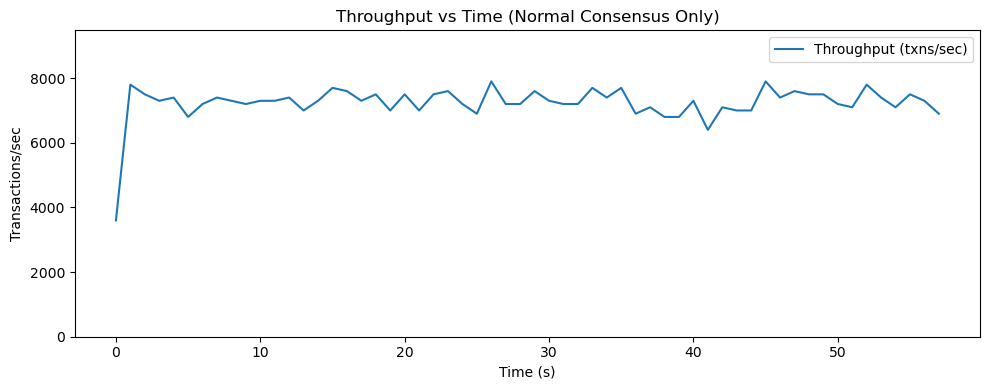

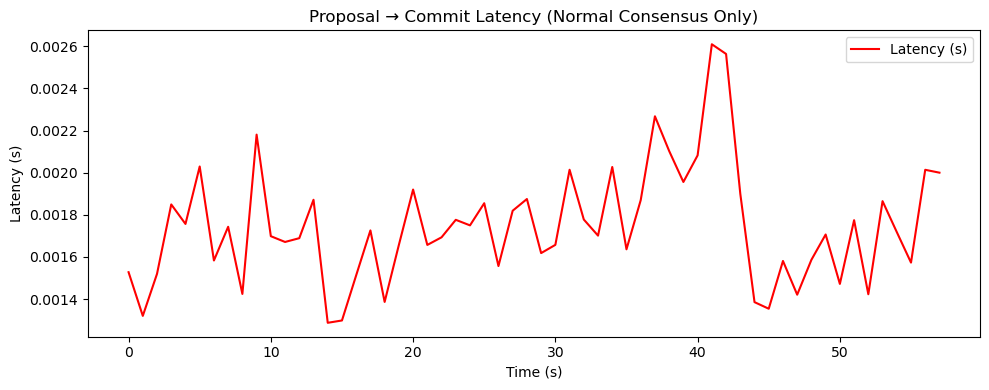


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 6000.00 txns/sec
Average latency: 0.0019 sec
Average latency: 1.87 ms

=== OVERALL STATISTICS ===
Total blocks committed: 4196
Total transactions: 419600
Total time: 57.45 seconds
Average throughput: 7304.12 txns/sec
Average latency: 0.0017 sec
Average latency: 1.74 ms
Min latency: 0.00 ms
Max latency: 16.00 ms
Processing: ../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log
Total proposals received: 3440
Total commits: 3441
COLLECT views found: 0
Normal consensus commits: 3440


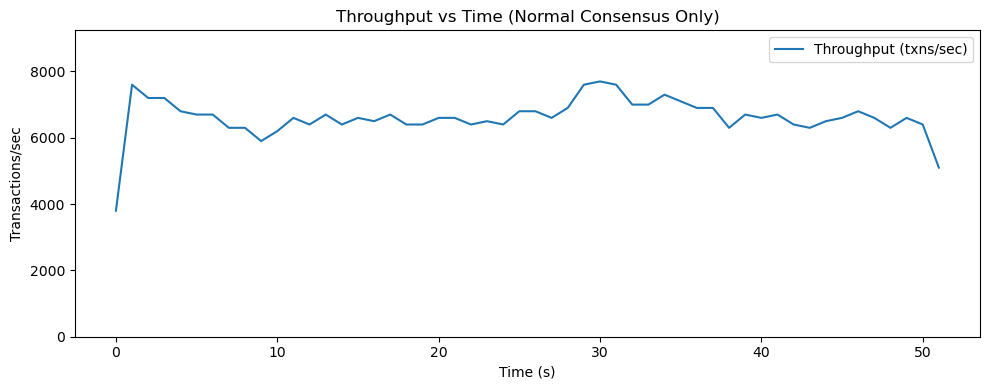

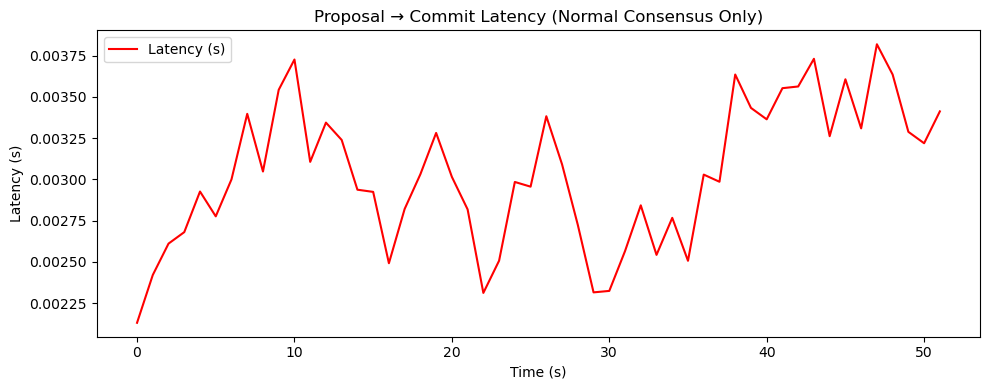


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 6000.00 txns/sec
Average latency: 0.0034 sec
Average latency: 3.37 ms

=== OVERALL STATISTICS ===
Total blocks committed: 3440
Total transactions: 344000
Total time: 51.31 seconds
Average throughput: 6703.95 txns/sec
Average latency: 0.0030 sec
Average latency: 3.03 ms
Min latency: 0.00 ms
Max latency: 19.00 ms
Processing: ../work/experiments/stellar-core/collection_16/tsm-sc-001/node2/stellar-core.log
Total proposals received: 2182
Total commits: 2183
COLLECT views found: 0
Normal consensus commits: 2182


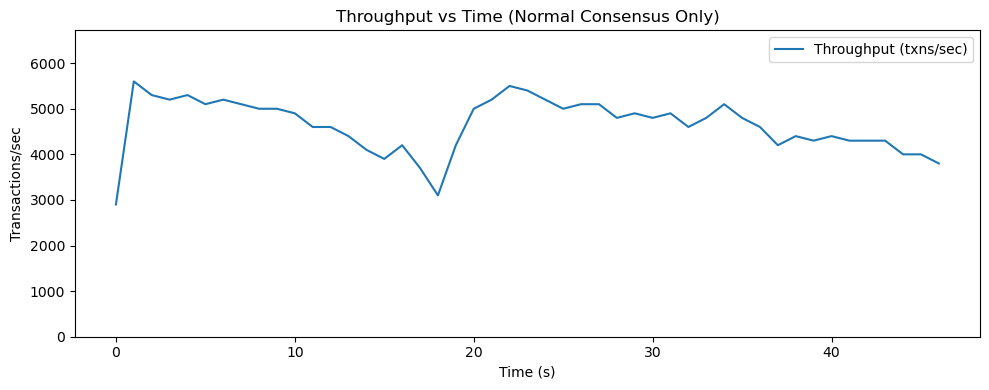

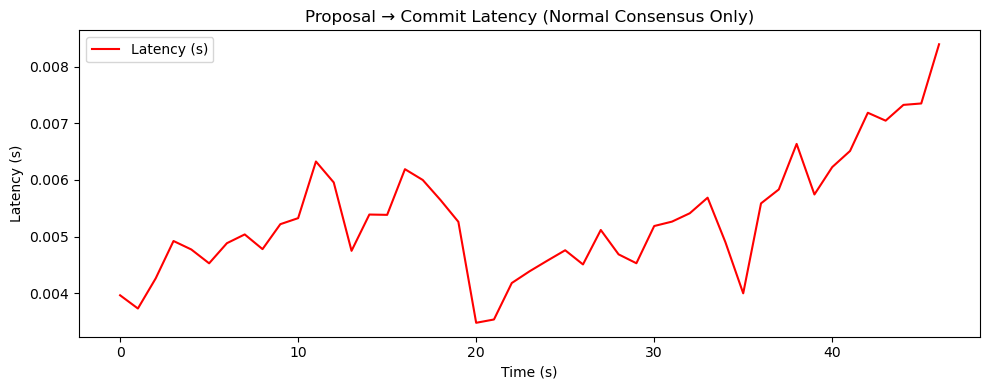


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 3997.34 txns/sec
Average latency: 0.0080 sec
Average latency: 8.00 ms

=== OVERALL STATISTICS ===
Total blocks committed: 2182
Total transactions: 218200
Total time: 46.45 seconds
Average throughput: 4697.73 txns/sec
Average latency: 0.0053 sec
Average latency: 5.26 ms
Min latency: 0.00 ms
Max latency: 26.00 ms
Processing: ../work/experiments/stellar-core/collection_48/tsm-sc-001/node2/stellar-core.log
Total proposals received: 3150
Total commits: 3150
COLLECT views found: 0
Normal consensus commits: 3150


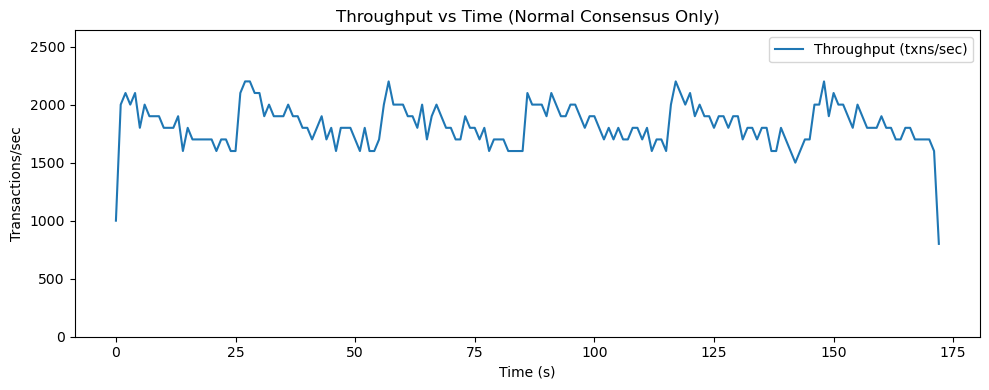

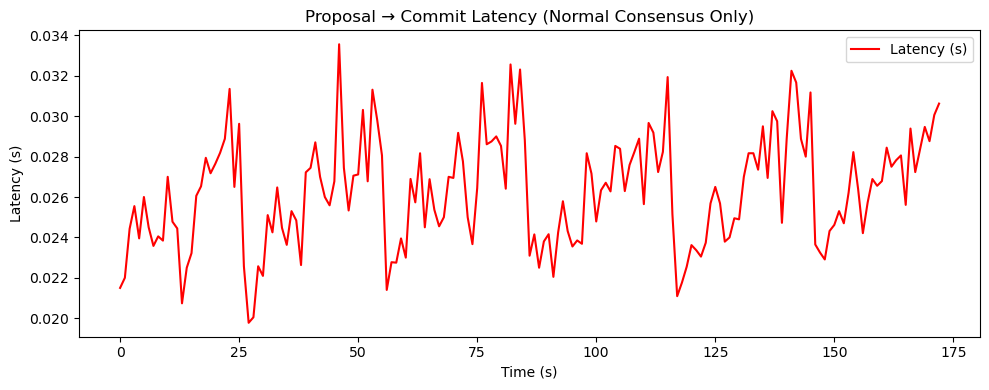


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 1671.77 txns/sec
Average latency: 0.0296 sec
Average latency: 29.57 ms

=== OVERALL STATISTICS ===
Total blocks committed: 3150
Total transactions: 315000
Total time: 172.00 seconds
Average throughput: 1831.43 txns/sec
Average latency: 0.0261 sec
Average latency: 26.07 ms
Min latency: 1.00 ms
Max latency: 60.00 ms


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_16/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/collection_48/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    print(f"Total proposals received: {len(propose_times)}")
    print(f"Total commits: {len(commit_times)}")
    print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        print("No normal consensus commits found.")
        print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    # ---- Statistics ----
    print(f"\n=== STATISTICS (Last 60 commits) ===")
    total_txns_last60 = lat_df['batch_size'].tail(60).sum()
    time_span_last60 = lat_df['time_sec'].tail(60).max() - lat_df['time_sec'].tail(60).min()
    
    print(f"Total transactions (last 60 blocks): {total_txns_last60}")
    print(f"Average throughput: {total_txns_last60 / max(time_span_last60, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]):.4f} sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]) * 1000:.2f} ms")
    
    print(f"\n=== OVERALL STATISTICS ===")
    total_txns = lat_df['batch_size'].sum()
    total_time = lat_df['time_sec'].max() - lat_df['time_sec'].min()
    
    print(f"Total blocks committed: {len(lat_df)}")
    print(f"Total transactions: {total_txns}")
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Average throughput: {total_txns / max(total_time, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(lat_df['latency']):.4f} sec")
    print(f"Average latency: {np.average(lat_df['latency']) * 1000:.2f} ms")
    print(f"Min latency: {np.min(lat_df['latency']) * 1000:.2f} ms")
    print(f"Max latency: {np.max(lat_df['latency']) * 1000:.2f} ms")

Processing: ../work/experiments/stellar-core/collection_100_rounds_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 11065
Total commits: 11064
COLLECT views found: 101
Normal consensus commits: 10862


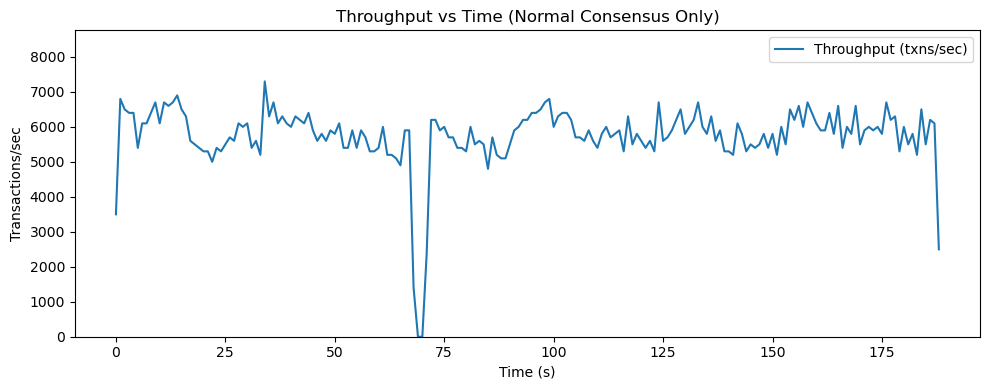

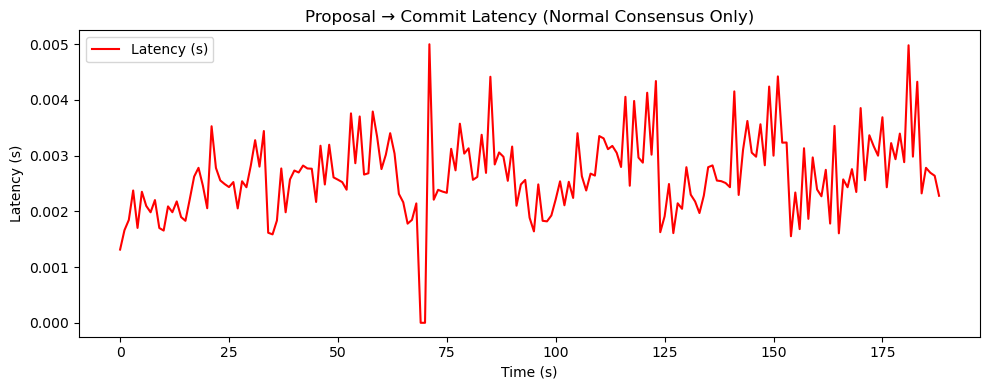


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 6000.00 txns/sec
Average latency: 0.0021 sec
Average latency: 2.07 ms

=== OVERALL STATISTICS ===
Total blocks committed: 10862
Total transactions: 1086200
Total time: 187.92 seconds
Average throughput: 5780.24 txns/sec
Average latency: 0.0027 sec
Average latency: 2.65 ms
Min latency: 0.00 ms
Max latency: 46.00 ms
Processing: ../work/experiments/stellar-core/collection_50_rounds_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 10955
Total commits: 10955
COLLECT views found: 51
Normal consensus commits: 10853


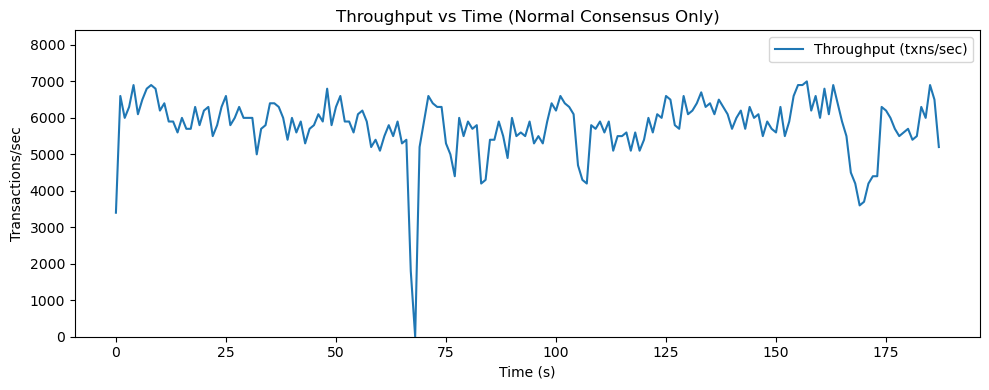

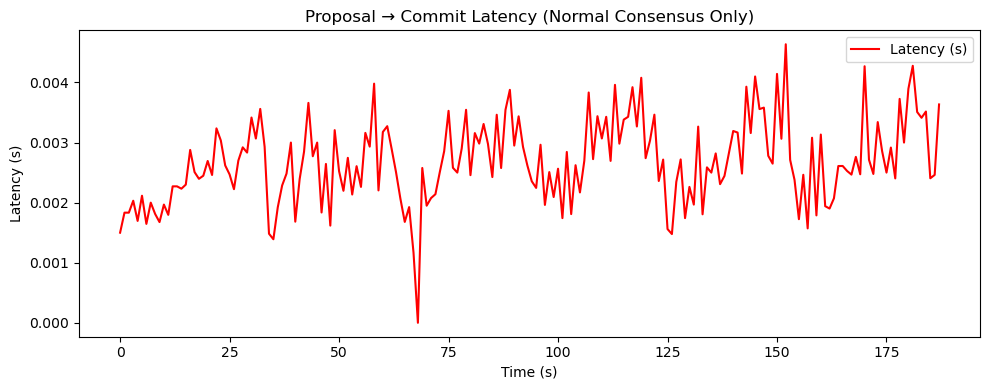


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 6000.00 txns/sec
Average latency: 0.0036 sec
Average latency: 3.55 ms

=== OVERALL STATISTICS ===
Total blocks committed: 10853
Total transactions: 1085300
Total time: 187.38 seconds
Average throughput: 5792.04 txns/sec
Average latency: 0.0027 sec
Average latency: 2.66 ms
Min latency: 0.00 ms
Max latency: 37.00 ms
Processing: ../work/experiments/stellar-core/collection_10_rounds_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 10547
Total commits: 10548
COLLECT views found: 10
Normal consensus commits: 10527


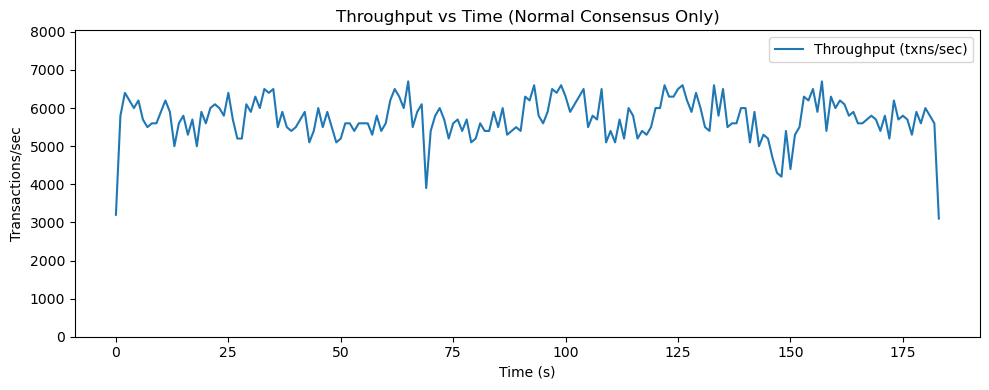

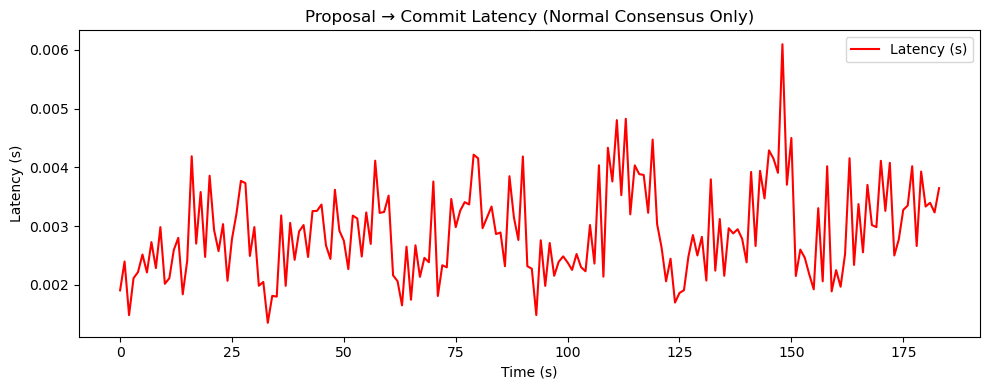


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 5128.21 txns/sec
Average latency: 0.0040 sec
Average latency: 4.03 ms

=== OVERALL STATISTICS ===
Total blocks committed: 10527
Total transactions: 1052700
Total time: 183.10 seconds
Average throughput: 5749.35 txns/sec
Average latency: 0.0029 sec
Average latency: 2.86 ms
Min latency: 1.00 ms
Max latency: 55.00 ms
Processing: ../work/experiments/stellar-core/collection_1_rounds_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 10914
Total commits: 10913
COLLECT views found: 1
Normal consensus commits: 10911


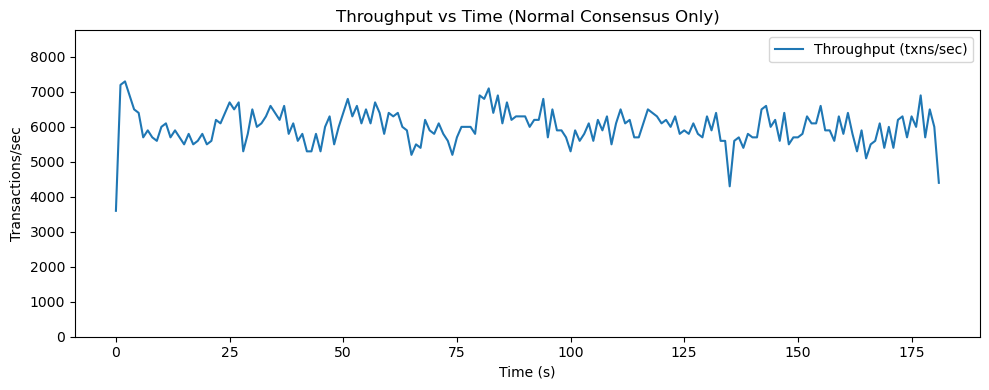

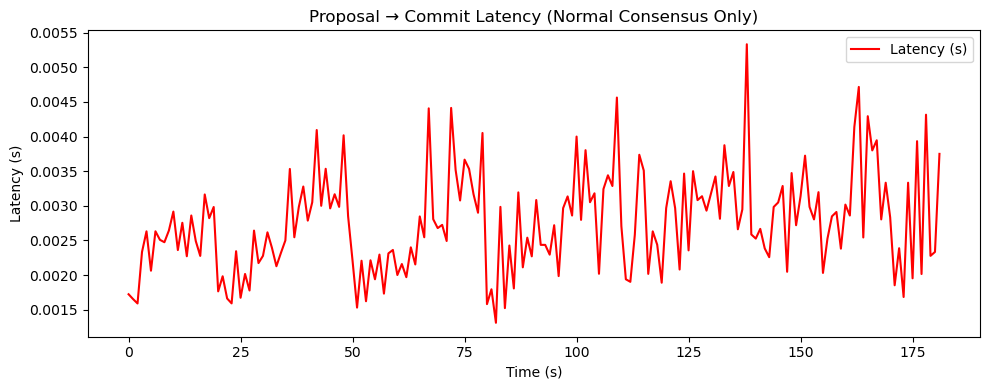


=== STATISTICS (Last 60 commits) ===
Total transactions (last 60 blocks): 6000
Average throughput: 5617.98 txns/sec
Average latency: 0.0036 sec
Average latency: 3.57 ms

=== OVERALL STATISTICS ===
Total blocks committed: 10911
Total transactions: 1091100
Total time: 181.27 seconds
Average throughput: 6019.20 txns/sec
Average latency: 0.0027 sec
Average latency: 2.72 ms
Min latency: 1.00 ms
Max latency: 56.00 ms


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_100_rounds_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_50_rounds_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_10_rounds_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_1_rounds_4/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    print(f"Total proposals received: {len(propose_times)}")
    print(f"Total commits: {len(commit_times)}")
    print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        print("No normal consensus commits found.")
        print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    # ---- Statistics ----
    print(f"\n=== STATISTICS (Last 60 commits) ===")
    total_txns_last60 = lat_df['batch_size'].tail(60).sum()
    time_span_last60 = lat_df['time_sec'].tail(60).max() - lat_df['time_sec'].tail(60).min()
    
    print(f"Total transactions (last 60 blocks): {total_txns_last60}")
    print(f"Average throughput: {total_txns_last60 / max(time_span_last60, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]):.4f} sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]) * 1000:.2f} ms")
    
    print(f"\n=== OVERALL STATISTICS ===")
    total_txns = lat_df['batch_size'].sum()
    total_time = lat_df['time_sec'].max() - lat_df['time_sec'].min()
    
    print(f"Total blocks committed: {len(lat_df)}")
    print(f"Total transactions: {total_txns}")
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Average throughput: {total_txns / max(total_time, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(lat_df['latency']):.4f} sec")
    print(f"Average latency: {np.average(lat_df['latency']) * 1000:.2f} ms")
    print(f"Min latency: {np.min(lat_df['latency']) * 1000:.2f} ms")
    print(f"Max latency: {np.max(lat_df['latency']) * 1000:.2f} ms")

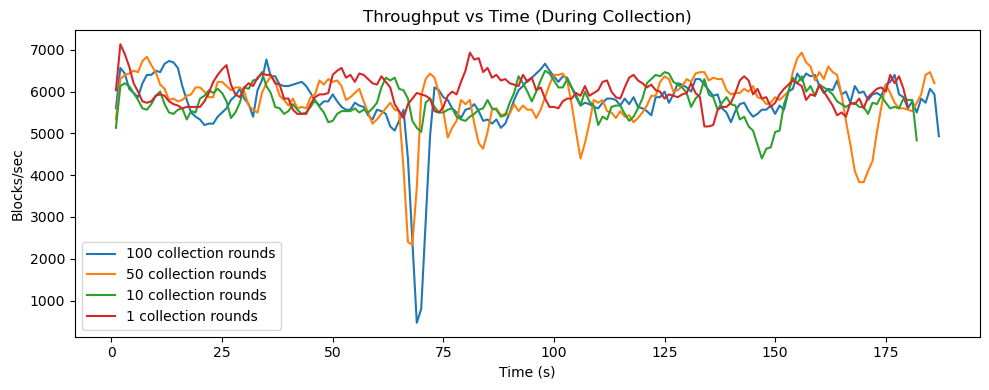

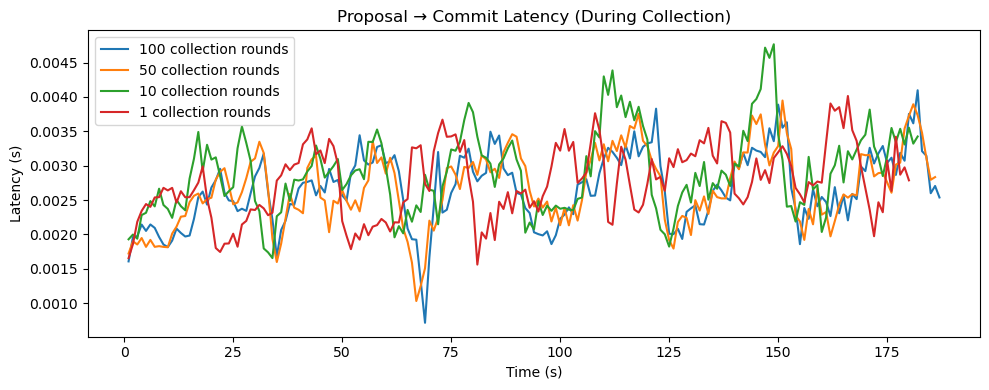

In [22]:


c_round_list = [100,50, 10, 1]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(10, 4))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index,
        throughput_ma.values,
        "-",
        label=f"{c_round_list[i]} collection rounds"
    )

plt.xlabel("Time (s)")
plt.ylabel("Blocks/sec")
plt.title("Throughput vs Time (During Collection)")
plt.legend()
plt.tight_layout()
plt.savefig("../throughput.png", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(10, 4))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index,
        latency_ma.values,
        "-",
        label=f"{c_round_list[i]} collection rounds"
    )

plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
plt.title("Proposal → Commit Latency (During Collection)")
plt.legend()
plt.tight_layout()
plt.savefig("../latency.png", dpi=150)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_10_rounds_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_10_rounds_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_10_rounds_16/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_10_rounds_48/tsm-sc-001/node2/stellar-core.log']

throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    print(f"Total proposals received: {len(propose_times)}")
    print(f"Total commits: {len(commit_times)}")
    print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        print("No normal consensus commits found.")
        print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    # ---- Statistics ----
    print(f"\n=== STATISTICS (Last 60 commits) ===")
    total_txns_last60 = lat_df['batch_size'].tail(60).sum()
    time_span_last60 = lat_df['time_sec'].tail(60).max() - lat_df['time_sec'].tail(60).min()
    
    print(f"Total transactions (last 60 blocks): {total_txns_last60}")
    print(f"Average throughput: {total_txns_last60 / max(time_span_last60, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]):.4f} sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]) * 1000:.2f} ms")
    
    print(f"\n=== OVERALL STATISTICS ===")
    total_txns = lat_df['batch_size'].sum()
    total_time = lat_df['time_sec'].max() - lat_df['time_sec'].min()
    
    print(f"Total blocks committed: {len(lat_df)}")
    print(f"Total transactions: {total_txns}")
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Average throughput: {total_txns / max(total_time, 1):.2f} txns/sec")
    print(f"Average latency: {np.average(lat_df['latency']):.4f} sec")
    print(f"Average latency: {np.average(lat_df['latency']) * 1000:.2f} ms")
    print(f"Min latency: {np.min(lat_df['latency']) * 1000:.2f} ms")
    print(f"Max latency: {np.max(lat_df['latency']) * 1000:.2f} ms")

In [ ]:


node_list = [100,50, 10, 1]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(10, 4))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index,
        throughput_ma.values,
        "-",
        label=f"{node_list[i]} nodes"
    )

plt.xlabel("Time (s)")
plt.ylabel("Blocks/sec")
plt.title("Throughput vs Time (During Collection)")
plt.legend()
plt.tight_layout()
plt.savefig("../throughput.png", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(10, 4))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index,
        latency_ma.values,
        "-",
        label=f"{node_list[i]} nodes"
    )

plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
plt.title("Proposal → Commit Latency (During Collection)")
plt.legend()
plt.tight_layout()
plt.savefig("../latency.png", dpi=150)
plt.show()
